In [5]:
import pandas as pd

url="https://raw.githubusercontent.com/voidful/tw_stocker/main/data/3037.csv"
pd.read_csv(url)

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2024-02-15 09:00:00+08:00,183.0,183.0,179.5,180.0,0,0.0,0.0
1,2024-02-15 09:05:00+08:00,179.5,180.0,178.5,178.5,507051,0.0,0.0
2,2024-02-15 09:10:00+08:00,179.0,179.0,178.0,178.5,427376,0.0,0.0
3,2024-02-15 09:15:00+08:00,178.5,179.5,178.5,179.0,301648,0.0,0.0
4,2024-02-15 09:20:00+08:00,178.5,178.5,178.0,178.5,223137,0.0,0.0
...,...,...,...,...,...,...,...,...
13449,2025-02-18 05:00:00+00:00,128.0,128.5,127.5,128.0,482619,0.0,0.0
13450,2025-02-18 05:05:00+00:00,127.5,128.0,127.5,127.5,202024,0.0,0.0
13451,2025-02-18 05:10:00+00:00,127.5,128.0,127.5,127.5,109922,0.0,0.0
13452,2025-02-18 05:15:00+00:00,128.0,128.0,127.5,127.5,119080,0.0,0.0


In [7]:
import vectorbt as vbt
import pandas as pd
import numpy as np
import fta
from strategy.dynamic_delay import trade

url = "https://raw.githubusercontent.com/voidful/tw_stocker/main/data/3037.csv"
df = pd.read_csv(url, index_col='Datetime')


ta = fta.TA_Features()
df_full = ta.get_all_indicators(df)

PARAMETER = {
    "delay": 15,
    "initial_money": 10000,
    "max_buy": 10,
    "max_sell": 10,
}

states_buy, states_sell, states_entry, states_exit, total_gains, invest = trade(df_full.close, **PARAMETER)

fees = 0 # 假設交易費用為 0
portfolio_kwargs = dict(size=np.inf, fees=float(fees), freq='5m')
portfolio = vbt.Portfolio.from_signals(df_full['close'], states_entry, states_exit, **portfolio_kwargs)
print(portfolio.stats())
portfolio.plot().show()

c:\Users\hankl\Desktop\dev\tw_stocker\testenv\lib\site-packages\fta\main.py:165: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\hankl\Desktop\dev\tw_stocker\testenv\lib\site-packages\fta\main.py:165: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`



slot 58: buy 10 units at price 181.5, total balance 8185.0
slot 136: buy 10 units at price 192.5, total balance 6260.0
slot 185: sell 10 units at price 190.0, total balance 8160.0
slot 245: sell 10 units at price 189.5, total balance 10055.0
slot 358: buy 10 units at price 189.5, total balance 8160.0
slot 416: buy 10 units at price 195.5, total balance 6205.0
slot 453: sell 10 units at price 178.0, total balance 7985.0
slot 514: buy 10 units at price 176.0, total balance 6225.0
slot 636: buy 10 units at price 180.0, total balance 4425.0
slot 680: buy 10 units at price 178.5, total balance 2640.0
slot 736: buy 10 units at price 174.0, total balance 900.0
slot 770: buy 5.0 units at price 173.0, total balance 35.0
slot 807: sell 10 units at price 175.5, total balance 1790.0
slot 861: sell 10 units at price 176.0, total balance 3550.0
slot 901: sell 10 units at price 177.5, total balance 5325.0
slot 963: sell 10 units at price 181.0, total balance 7135.0
slot 1020: buy 10 units at price 17

c:\Users\hankl\Desktop\dev\tw_stocker\testenv\lib\site-packages\fta\main.py:165: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

c:\Users\hankl\Desktop\dev\tw_stocker\testenv\lib\site-packages\fta\main.py:165: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`



slot 58: buy 10 units at price 181.5, total balance 8185.0
slot 136: buy 10 units at price 192.5, total balance 6260.0
slot 185: sell 10 units at price 190.0, total balance 8160.0
slot 245: sell 10 units at price 189.5, total balance 10055.0
slot 358: buy 10 units at price 189.5, total balance 8160.0
slot 416: buy 10 units at price 195.5, total balance 6205.0
slot 453: sell 10 units at price 178.0, total balance 7985.0
slot 514: buy 10 units at price 176.0, total balance 6225.0
slot 636: buy 10 units at price 180.0, total balance 4425.0
slot 680: buy 10 units at price 178.5, total balance 2640.0
slot 736: buy 10 units at price 174.0, total balance 900.0
slot 770: buy 5.0 units at price 173.0, total balance 35.0
slot 807: sell 10 units at price 175.5, total balance 1790.0
slot 861: sell 10 units at price 176.0, total balance 3550.0
slot 901: sell 10 units at price 177.5, total balance 5325.0
slot 963: sell 10 units at price 181.0, total balance 7135.0
slot 1020: buy 10 units at price 17

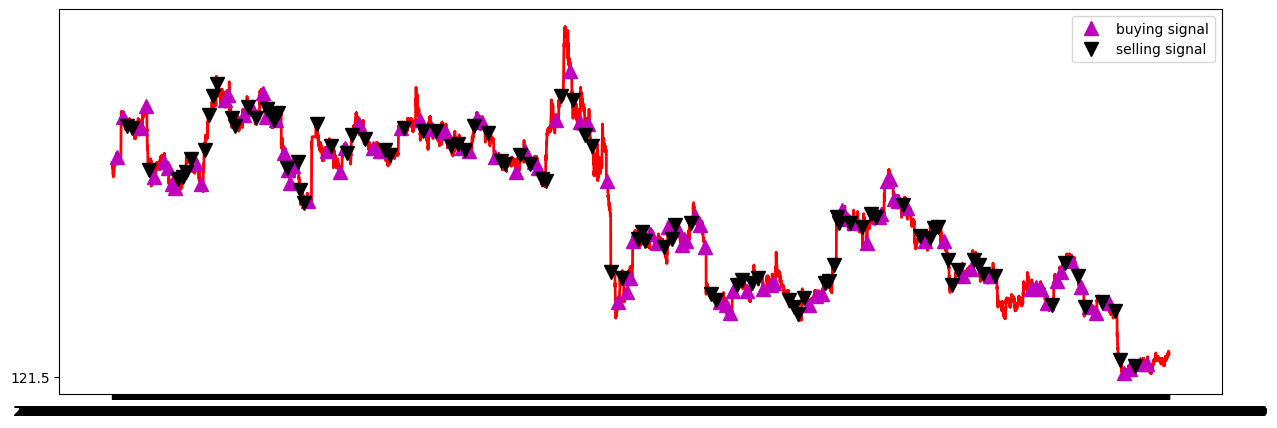

In [8]:
from matplotlib import pyplot as plt
import pandas as pd
import fta
from strategy.dynamic_delay import trade

url = "https://raw.githubusercontent.com/voidful/tw_stocker/main/data/3037.csv"
df = pd.read_csv(url, index_col='Datetime')


ta = fta.TA_Features()
df_full = ta.get_all_indicators(df)

PARAMETER = {
    "delay": 15,
    "initial_money": 10000,
    "max_buy": 10,
    "max_sell": 10,
}

states_buy, states_sell, states_entry, states_exit, total_gains, invest = trade(df_full.close, **PARAMETER)

close = df_full['close']
fig = plt.figure(figsize = (15,5))
plt.plot(close, color='r', lw=2.)
plt.plot(close, '^', markersize=10, color='m', label = 'buying signal', markevery = states_buy)
plt.plot(close, 'v', markersize=10, color='k', label = 'selling signal', markevery = states_sell)
plt.legend()

plt.yticks(np.arange(min(close), max(close)+1, 100))

plt.show()